In [1]:
#
import numpy as np
import xarray as xr
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER 
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import os
import pandas as pd
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection
from shapely.geometry import Polygon, Point
import cmaps
import matplotlib.ticker as ticker
from PyEMD import EEMD
from scipy.fft import fft, fftfreq
from scipy.integrate import simpson
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.signal import butter, filtfilt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress
import seawater
import warnings
import scipy
from scipy.ndimage import gaussian_filter
from scipy.stats import genextreme
from scipy.interpolate import RegularGridInterpolator
warnings.filterwarnings('ignore')

def add_right_cax_big (ax0, ax3, pad, width) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax3. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x1 + pad, #ax0 的右边 (x1) 加上 pad 的值
        axpos2.y0,
        axpos1.x1 + pad + width,#颜色条的宽度
        axpos1.y1
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_bottom_cax_big (ax0, ax3, pad, width) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax3. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x0,
        axpos1.y0 - pad -width,
        axpos2.x1,
        axpos1.y0 - pad
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

plt.rcParams['font.sans-serif']=['Helvetica']

/tmp/ipykernel_41780/387287271.py:27: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater


In [2]:
def is_point_inside_polygon(point, polygon):
    point_obj = Point(point[0], point[1])
    return polygon.contains(point_obj) #不规则图形掩码

def Area_mask(data,lat0,lat1,lon0,lon1,Points):
    mask = data.copy()
    try:
        mask.loc[{'lat':slice(lat0,lat1),'lon':slice(lon0,lon1)}] = np.nan
    except KeyError:
        mask.loc[{'latitude':slice(lat0,lat1),'longitude':slice(lon0,lon1)}] = np.nan
    
    polygon = Polygon(Points)

    it = np.ndindex(np.squeeze(data[0].T).shape)
    for idx in it:
        lon_idx = idx[0]
        lat_idx = idx[1]
        try:
            lon = mask.lon[lon_idx]
            lat = mask.lat[lat_idx]
        except AttributeError:
            lon = mask.longitude[lon_idx]
            lat = mask.latitude[lat_idx]
        point = (lon,lat)
        if is_point_inside_polygon(point, polygon):
            mask[:,lat_idx, lon_idx] = np.nan
    return mask

def weight_mean(data, dx, dy):
    weight = dx*dy
    res = np.full_like(data[:,0,0],np.nan)
    for i in range(np.shape(data)[0]):
        w = weight.copy()
        w[np.isnan(data[i])] = np.nan
        res[i] = np.nansum(data[i,:,:]*w,axis=(-2,-1))/np.nansum(w)
    return res

def weight_mean_4d(data, dx, dy):
    weight = dx*dy
    res = np.full_like(data[:,:,0,0],np.nan)
    for i in range(np.shape(data)[0]):
        for j in range(np.shape(data)[1]):
            w = weight.copy()
            w[np.isnan(data[i,j,:,:])] = np.nan
            res[i,j] = np.nansum(data[i,j,:,:]*w,axis=(-2,-1))/np.nansum(w)
    return res

def weight_mean_4d_full(data, dx, dy, dz):
    weight = dx*dy*dz
    res = np.full_like(data[:,0,0,0],np.nan)
    for i in range(np.shape(data)[0]):
        w = weight.copy()
        w[np.isnan(data[i,:,:,:])] = np.nan
        res[i] = np.nansum(data[i,:,:]*w,axis=(-3,-2,-1))/np.nansum(w)
    return res

def eemd(S,para = False):
    eemd = EEMD()
    eemd.parallel = para
    if para:
        eemd.processes = 5
    eemd.trails = 500
    eemd.noise_seed(1)
    eIMFs = eemd.eemd(S, np.arange(len(S)))
    period = []
    for i in range(np.shape(eIMFs)[0]):
        frequencies = fftfreq(len(eIMFs[i]), 1)
        fft_values = fft(eIMFs[i])
        positive_frequencies = frequencies[:len(eIMFs[i])//2]
        positive_fft_values = np.abs(fft_values[:len(eIMFs[i])//2])
        dominant_frequency = positive_frequencies[np.argmax(positive_fft_values)]
        period.append(1 / dominant_frequency)
    period = np.array(period)
    res0 = np.sum(eIMFs[period>20],0)
    res1 = gaussian_filter(S-np.sum(eIMFs,axis=0),3)
    res = res0 + res1
    return res

def linear_trend(data):
    slope = np.full_like(data[0],np.nan)
    p = np.full_like(data[0],np.nan)
    for i in range(np.shape(data)[1]):
        for j in range(np.shape(data)[2]):
            slope[i,j], _, _, p[i,j], _ = linregress(np.arange(len(data[:,i,j])),data[:,i,j])
    return slope, p

def return_level(T, shape, loc, scale):
    rp = np.zeros_like(T)
    for i in range(len(T)):
        p = 1 - 1/T[i]
        rp[i] = genextreme.ppf(p, shape, loc=loc, scale=scale)
    return rp

In [3]:
def Cal_mon_clim(data):
    data_bar = np.nanmean(np.reshape(np.array(data[120:480]),(30,12,np.shape(data)[1],np.shape(data)[2])),0)
    data_bar = np.tile(data_bar,(50,1,1))[:np.shape(data)[0]]
    data_prime = data - data_bar
    return data_bar, data_prime

def diag_period(data,t1,t2,mask,n,dx,dy):
    res = np.zeros(len(data))
    for i in range(len(data)):
        res[i] = annual_integral_1(weight_mean(data[i]*mask,dx,dy),t1,t2)[n]
    res = np.append(res,res[0]-np.sum(res[1:]))
    res = np.insert(res,1,np.sum(res[1:4]))
    res = np.insert(res,5,np.sum(res[5:8]))
    res = np.insert(res,9,np.sum(res[9:12]))
    return res

def diag_period_era(data,t1,t2,mask,n,dx,dy):
    res = np.zeros(len(data))
    for i in range(len(data)):
        res[i] = annual_integral_1(weight_mean(data[i]*mask,dx,dy),t1,t2)[n]
    return res

def convolve_ignore_nan(data, r, sig):
    # 获取数据的形状
    output = np.zeros_like(data)
    size = 2*r+1
    center = r
    # 创建一个空的二维数组
    kernel = np.fromiter(
        (np.exp(-((x - center)**2 + (y - center)**2) / (2 * sig**2)) 
         for x in range(size) for y in range(size)),
        dtype=float
    ).reshape((size, size))
    # 遍历每个位置
    for i in range(0, data.shape[0]):
        for j in range(0, data.shape[1]):
            if ((i < r) | ((i+r)>=data.shape[0])):
                output[i,j] = data[i,j]
            else:
                if (j >= (data.shape[1] - r)):
                    region = np.append(data[i-r:i+r+1, j-r:],data[i-r:i+r+1, :r+1+j-data.shape[1]],1)
                elif (j < r):
                    region = np.append(data[i-r:i+r+1, -r+j:], data[i-r:i+r+1, :j+r+1],1)
                else:
                    region = data[i-r:i+r+1, j-r:j+r+1]
                
                # 只选择非 NaN 元素
                valid_values = region[~np.isnan(region)]
                valid_kernel = kernel[~np.isnan(region)]
                
                # 计算卷积，跳过 NaN
                if valid_values.size > 0:
                    output[i, j] = np.sum(valid_values * valid_kernel) / np.sum(valid_kernel)
    output[np.isnan(data)] = np.nan
    return output

def annual_integral_1(data,n1,n2):
    res = np.zeros(44)
    for i in range(44):
        # res[i] = data[12*i+n1]*60*24*3600
        res[i] = (simpson(data[12*i+n1-1:12*i+n2]))*30*24*3600
        # res[i] = (np.sum(data[12*i+n1:12*i+n2-1])+(data[12*i+n1-1]+data[12*i+n2-1])/2)*30*24*3600
    return res

def annual_diff_1(data,n1,n2):
    res = np.zeros(44)
    for i in range(44):
        res[i] = data[12*i+n2-1]-data[12*i+n1-1]
    return res

def annual_integral_2(data,n1,n2):
    res = np.zeros((44,168,110))
    for i in range(44):
        # res[i] = data[12*i+n1]*60*24*3600
        res[i] = (simpson(data[12*i+n1-1:12*i+n2],axis=0))*30*24*3600
        # res[i] = (np.sum(data[12*i+n1:12*i+n2-1],0)+(data[12*i+n1-1]+data[12*i+n2-1])/2)*30*24*3600
    return res

def annual_diff_2(data,n1,n2):
    res = np.zeros((44,168,110))
    for i in range(44):
        res[i] = data[12*i+n2-1]-data[12*i+n1-1]
    return res

def cal_transport_vert(lon,lat0,lat1):
    ind = (Lon==lon)&(Lat>lat0)&(Lat<lat1)
    sv = np.nansum(u_mld[:,ind]*dy[ind]*np.array(mld)[:,ind],axis=-1)
    return sv

def cal_transport_hor(lat,lon0,lon1):
    ind = (Lat==lat)&(Lon>lon0)&(Lon<lon1)
    sv = np.nansum(v_mld[:,ind]*dx[ind]*np.array(mld)[:,ind],axis=-1)
    return sv

def fit_uncert(x,y,k,d):
    y_pred = d + k * x
    t_crit = scipy.stats.t.ppf(1 - 0.05/2, len(x)-2)
    res  = y - y_pred
    x_fit = np.linspace(-6, 6, 200)
    y_fit = d + k * x_fit
    s_err = np.sqrt(np.sum(res**2) / (len(x)-2))
    SSxx   = np.sum((x - np.mean(x))**2)
    se_fit = s_err * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / SSxx)
    ci     = t_crit * se_fit
    return x_fit, y_fit, ci

In [4]:
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(S, cutoff, fs=1, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    res = filtfilt(b, a, S)
    return res

def tscale_filter(data):
    long = gaussian_filter(data,192/1.414) #32years
    multidecade = gaussian_filter(data-long,48/1.414) #8-32years
    interan = gaussian_filter(data-long-multidecade,12/1.414)  #2years
    return long, multidecade, interan

def sliding_corr(x, y, window_size):
    n = len(x)
    corr_values = np.empty(n - 2*window_size)
    p_values = np.empty(n - 2*window_size)
    for i in range(window_size, n - window_size):
        window_x = x[i - window_size : i + window_size+1]
        window_y = y[i - window_size : i + window_size+1]
        corr,p = pearsonr(window_x, window_y)
        corr_values[i-window_size] = corr
        p_values[i-window_size] = p
    return corr_values, p_values

In [5]:
def OISST_series():
    fpath = '/2024data2/yangsl/Yangsl/OISST/OISST/OISST_1982-2024.nc'  # 你的海平面温度数据文件路径
    sst = xr.open_dataset(fpath)['sst'].sel(lon=slice(104, 131.5),lat=slice(0,42)).squeeze()
    sst = sst.sel(time=~((sst.time.dt.month == 2) & (sst.time.dt.day == 29)))
    Points_E = [(131.5, 31.2),(130.5, 30.4),(129.5, 28.3),(129, 27.7),(128, 26.6),(125.3, 24.75),(123.75, 24.3),(123, 23.9),(131.5, 23.9)]
    Points_E1 = [(130.5, 34),(130.2, 35),(129.5, 35.5),(131.5, 35.5),(131.5, 34)]
    Points_S = [(120, 12),(119.5, 11),(118.5, 9.5),(117.5, 8.7),(117.2, 7.3),(117.2, 6),(121.5,6),(121.5,12)]
    sst_ES = Area_mask(sst,35.5,42,127,131.5,Points_E)
    sst_ES = Area_mask(sst_ES,0,6,117.2,122,Points_E1)
    sst_ES = Area_mask(sst_ES,0,24,121.5,131.5,Points_S)
    mask_ES = np.ones_like(sst_ES[0])
    mask_ES[np.isnan(sst_ES[0])] = np.nan
    return sst, mask_ES

In [6]:
def tscale_filter(data):
    long = gaussian_filter(data,192/1.414) #32years
    multidecade = gaussian_filter(data-long,48/1.414) #8-32years
    interan = gaussian_filter(data-long-multidecade,12/1.414)  #2years
    res = (long + multidecade + interan)
    return res

def sel_year(data,m1,m2):
    res = np.zeros((int(np.shape(data)[0]/12),np.shape(data)[1],np.shape(data)[2]))
    for i in range(int(np.shape(data)[0]/12)):
        res[i] = np.mean(data[12*i+m1-1:12*i+m2],0)
    return res

def sel_year_1d(data,m1,m2):
    res = np.zeros(int(len(data)/12))
    for i in range(int(len(data)/12)):
        res[i] = np.mean(data[12*i+m1-1:12*i+m2])
    return res

In [7]:
# 温度提取
sst_ES_oisst, mask_ES_oisst = OISST_series()
# 时间和经纬度
date = pd.date_range('2023-01-01', '2023-12-31', freq='D')
date_year_oisst = pd.date_range('1982-01-01', '2024-12-31', freq='YE')
date_month_oisst = pd.date_range('1982-01-01', '2024-12-31', freq='ME')
Lon, Lat = np.meshgrid(sst_ES_oisst.lon, sst_ES_oisst.lat)
dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)

In [8]:
# 获取8-9月数据和高温掩膜
sst_ES_oisst_89 = sst_ES_oisst.sel(time=((sst_ES_oisst["time.month"] == 8) | (sst_ES_oisst["time.month"] == 9)))
base_ES_89 = np.mean(sst_ES_oisst_89.sel(time=((sst_ES_oisst_89["time.year"] < 2021) & (sst_ES_oisst_89["time.year"] > 1990))),0)
std_ES_89 = np.std(sst_ES_oisst_89.sel(time=((sst_ES_oisst_89["time.year"] < 2021) & (sst_ES_oisst_89["time.year"] > 1990))).groupby("time.year").mean(dim="time"),0)
year_ES_89 = sst_ES_oisst_89.resample(time='YE').mean()

mask_max = np.full_like(year_ES_89[0],np.nan)
mask_max[np.where(np.max(year_ES_89[:-1],0) <= year_ES_89[-1])] = 1
mask_hightemp = np.full_like(year_ES_89[0],np.nan)
mask_hightemp[(np.mean(sst_ES_oisst_89[-61:],0)-base_ES_89)/std_ES_89>3] = 1
mask_hightemp[np.isnan(mask_ES_oisst)] = np.nan
###
mask_hightemp = mask_ES_oisst.copy()
mask_hightemp[((Lon<120.5)&(Lat<25))|(Lat<23)] = np.nan

sst_high = weight_mean(sst_ES_oisst*mask_hightemp,dx,dy)
base_high = np.mean(np.reshape(sst_high[9*365:39*365],(30,365)),0)
std_high = np.std(np.reshape(sst_high[9*365:39*365],(30,365)),0)
year_high_89 = weight_mean(year_ES_89*mask_hightemp,dx,dy)
year_ES = sst_ES_oisst.resample(time='YE').mean()
year_high = weight_mean(year_ES*mask_hightemp,dx,dy)

mask_land = np.full_like(mask_hightemp,np.nan)
mask_land[np.isnan(sst_ES_oisst[0])] = 1

In [9]:
# 打开三维文件
mld = xr.open_dataset('ORAS5/mld.nc')['somxl030'].interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
qnet = xr.open_dataset('ORAS5/qnet.nc')['sohefldo'].interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
tx = xr.open_dataset('ORAS5/taox.nc')['sozotaux'].interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
ty = xr.open_dataset('ORAS5/taoy.nc')['sometauy'].interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)

In [10]:
# 打开四维文件
u = xr.open_dataset('ORAS5/U.nc')['vozocrtx'].sel(depthu=slice(0,450)).interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
v = xr.open_dataset('ORAS5/V.nc')['vomecrty'].sel(depthv=slice(0,450)).interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
t = xr.open_dataset('ORAS5/T.nc')['votemper'].sel(deptht=slice(0,450)).interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)

In [16]:
# 混合层平均和垂直速度计算
depth = u.depthu.data
u_mld = u.where(u.depthu <= mld, 0)
v_mld = v.where(v.depthv <= mld, 0)
t_mld = t.where(t.deptht <= mld, 0)
u_mld = u_mld.fillna(0)
v_mld = v_mld.fillna(0)
t_mld = t_mld.fillna(0)

depth_new = np.swapaxes(np.swapaxes(np.tile(depth,(528,168,110,1)),1,3),2,3)
depth_new[t_mld==0] = 0
depth_new = np.nanmax(depth_new,axis=1)
depth_new[depth_new==0] = np.nan

depth_b = np.swapaxes(np.swapaxes(np.tile(depth,(528,168,110,1)),1,3),2,3)
depth_b[t_mld!=0] = np.nan
depth_b = np.nanargmin(depth_b,axis=1)
tb = t.isel(deptht=xr.DataArray(depth_b, dims=['time_counter', 'lat', 'lon']))
ub = u.isel(depthu=xr.DataArray(depth_b, dims=['time_counter', 'lat', 'lon']))
vb = v.isel(depthv=xr.DataArray(depth_b, dims=['time_counter', 'lat', 'lon']))
u_mld = (np.sum(u_mld*np.gradient(depth)[None,:,None,None],axis=1)/np.sum((u_mld!=0)*np.gradient(depth)[None,:,None,None],axis=1)).values
v_mld = (np.sum(v_mld*np.gradient(depth)[None,:,None,None],axis=1)/np.sum((v_mld!=0)*np.gradient(depth)[None,:,None,None],axis=1)).values
t_mld = (np.sum(t_mld*np.gradient(depth)[None,:,None,None],axis=1)/np.sum((t_mld!=0)*np.gradient(depth)[None,:,None,None],axis=1)).values

In [11]:
def sel_pos(data):
    data1 = data.copy()
    data1[data<0] = 0
    return data1

In [12]:
def add_in_cax_up (ax, padx, pady, width, k) :#pad控制颜色条与 ax0 之间的间距
    axpos=ax. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos.x0 + padx,
        axpos.y1 - pady -width,
        axpos.x0 + padx + (axpos.x1 - axpos.x0)*k,
        axpos.y1 - pady
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

In [13]:
def IAP_series():
    fpath = '/2024data2/yangsl/Yangsl/IAPv4_Temp_monthly/IAPv4*.nc'  # 你的海平面温度数据文件路径
    t_ES = xr.open_mfdataset(fpath)['temp'].sel(lon=slice(104.5, 131.375),lat=slice(0,42),depth_std=slice(1,400)).transpose("time", "depth_std", "lat", "lon")
    t_ES['time'] = pd.date_range(start='1940-01-01', end='2024-12-31', freq='ME')
    Lon, Lat = np.meshgrid(t_ES.lon, t_ES.lat)
    depth = t_ES.depth_std.values
    t_ES = t_ES.sel(time=t_ES["time.year"]>=1981)
    t_ES = t_ES.sel(time=(t_ES["time.month"]==8)|(t_ES["time.month"]==9)).groupby('time.year').mean(dim='time').values
    fpath = '/2024data2/yangsl/Yangsl/IAPv2_SAL_monthly/IAPv2*.nc'  # 你的海平面温度数据文件路径
    s_ES = xr.open_mfdataset(fpath)['salinity'].sel(lon=slice(104.5, 131.375),lat=slice(0,42),depth_std=slice(1,400)).transpose("time", "depth_std", "lat", "lon")
    s_ES['time'] = pd.date_range(start='1980-01-01', end='2024-12-31', freq='ME')
    s_ES = s_ES.sel(time=s_ES["time.year"]>=1981)
    s_ES = s_ES.sel(time=(s_ES["time.month"]==8)|(s_ES["time.month"]==9)).groupby('time.year').mean(dim='time').values
    dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
    dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)
    return t_ES, s_ES, dx, dy, Lon, Lat, depth

In [14]:
t_IAP, s_IAP, dx_IAP, dy_IAP, Lon_IAP, Lat_IAP, depth_IAP = IAP_series()
rho_IAP = seawater.pden(s_IAP,t_IAP,depth_IAP[None,:,None,None])
rho_IAP_t = seawater.pden(np.mean(s_IAP[10:40],0)[None,:,:,:],t_IAP,depth_IAP[None,:,None,None])
rho_IAP_s = seawater.pden(s_IAP,np.mean(t_IAP[10:40],0)[None,:,:,:],depth_IAP[None,:,None,None])
N2_IAP = (9.81/1026*np.gradient(rho_IAP,axis=-1)/np.gradient(depth_IAP)[None,:,None,None])
N2_IAP_t = (9.81/1026*np.gradient(rho_IAP_t,axis=-1)/np.gradient(depth_IAP)[None,:,None,None])
N2_IAP_s = (9.81/1026*np.gradient(rho_IAP_s,axis=-1)/np.gradient(depth_IAP)[None,:,None,None])
interp_func = RegularGridInterpolator((sst_ES_oisst.lat,sst_ES_oisst.lon), mask_hightemp, method='nearest')
IAP_grid = np.column_stack([Lat_IAP.ravel(),Lon_IAP.ravel()])
mask_hightemp_IAP = interp_func(IAP_grid).reshape(np.shape(Lon_IAP))
mask_hightemp_IAP[np.isnan(t_IAP[0,0])] = np.nan

In [17]:
s = xr.open_dataset('ORAS5/S.nc')['vosaline'].sel(deptht=slice(0,450)).interp(lon=sst_ES_oisst.lon,lat=sst_ES_oisst.lat)
s_year = s.sel(time_counter=s['time_counter'].dt.month.isin([8,9])).groupby('time_counter.year').mean(dim='time_counter').squeeze()
t_year = t.sel(time_counter=s['time_counter'].dt.month.isin([8,9])).groupby('time_counter.year').mean(dim='time_counter').squeeze()
rho = seawater.pden(s_year,t_year,depth[None,:,None,None])
N2 = (9.81/1026*np.gradient(rho,axis=1)/np.gradient(depth)[None,:,None,None])

In [18]:
mld_IAP = np.zeros_like(t_IAP[:,0,:,:])
for i in range(len(t_IAP[:,0,0,0])):
    for m in range(len(t_IAP[0,0,:,0])):
        for n in range(len(t_IAP[0,0,0,:])):
            mld_IAP[i,m,n] = depth_IAP[int(np.min(np.append(np.where(rho_IAP[i,:,m,n] >= rho_IAP[i,0,m,n]+0.03),40)))]
mld_IAP[mld_IAP>379.9] = np.nan

In [19]:
rho_t = seawater.pden(np.mean(s_year[10:40],0).values[None,:,:,:],t_year.values,depth[None,:,None,None])
N2_t = (9.81/1026*np.gradient(rho_t,axis=1)/np.gradient(depth)[None,:,None,None])
rho_s = seawater.pden(s_year.values,np.mean(t_year[10:40],0).values[None,:,:,:],depth[None,:,None,None])
N2_s = (9.81/1026*np.gradient(rho_s,axis=1)/np.gradient(depth)[None,:,None,None])

In [20]:
N2_IAP_prof = weight_mean_4d(N2_IAP*mask_hightemp_IAP,dx_IAP,dy_IAP)
N2_IAP_prof = N2_IAP_prof - np.mean(N2_IAP_prof[10:40],0)
N2_t_IAP_prof = weight_mean_4d(N2_IAP_t*mask_hightemp_IAP,dx_IAP,dy_IAP)
N2_t_IAP_prof = N2_t_IAP_prof - np.mean(N2_t_IAP_prof[10:40],0)
N2_s_IAP_prof = weight_mean_4d(N2_IAP_s*mask_hightemp_IAP,dx_IAP,dy_IAP)
N2_s_IAP_prof = N2_s_IAP_prof - np.mean(N2_s_IAP_prof[10:40],0)
temp_IAP_prof = weight_mean_4d(t_IAP*mask_hightemp_IAP,dx_IAP,dy_IAP)
temp_IAP_prof = temp_IAP_prof - np.mean(temp_IAP_prof[10:40],0)

N2_prof = weight_mean_4d(N2*mask_hightemp,dx,dy)
N2_prof = N2_prof - np.mean(N2_prof[10:40],0)
N2_t_prof = weight_mean_4d(N2_t*mask_hightemp,dx,dy)
N2_t_prof = N2_t_prof - np.mean(N2_t_prof[10:40],0)
N2_s_prof = weight_mean_4d(N2_s*mask_hightemp,dx,dy)
N2_s_prof = N2_s_prof - np.mean(N2_s_prof[10:40],0)
temp_prof = weight_mean_4d(t_year*mask_hightemp,dx,dy)
temp_prof = temp_prof - np.mean(temp_prof[10:40],0)

mld_prof = weight_mean(sel_year(mld,8,9),dx,dy)
u_year_89 = sel_year(u_mld,8,9)
v_year_89 = sel_year(v_mld,8,9)
mld_year_89 = sel_year(mld,8,9)
t_year_89 = sel_year(t_mld,8,9)
N2_year_89 = np.nansum(N2[:,:24]*np.gradient(depth)[None,:24,None,None],axis=1)

In [22]:
mld_his = weight_mean(sel_year(mld,8,9)*mask_hightemp,dx,dy)
# mld_IAP_his = weight_mean(mld_IAP*mask_hightemp_IAP,dx_IAP,dy_IAP)
mask_K = np.full_like(u_mld[0],np.nan)
mask_K[np.mean((u[120:480,0]**2+v[120:480,0]**2)**.5,0)>0.4] = 1
mask_K[np.isnan(mask_hightemp)] = np.nan
mask_K[Lat<23] = np.nan
uv_his = weight_mean(sel_year((u_mld**2+v_mld**2)**.5,8,9)*mask_K,dx,dy)
vin_his = np.nanmean(sel_year(v_mld[:,95:100,71:80],8,9),axis=(-2,-1))
dtdy = weight_mean(sel_year(np.gradient(t_mld,axis=1),8,9)*mask_K,dx,dy)
# uout_his = np.nanmean(sel_year(u_mld[:,115:125,100:105],8,9),axis=(-2,-1))

In [23]:
Lon3, Lat3, Dep3 = np.meshgrid(sst_ES_oisst.lon, sst_ES_oisst.lat, depth[:31])
dx3 = np.swapaxes(np.swapaxes(6371*1e3*np.pi/180*np.gradient(Lon3,axis=1)*np.cos(np.radians(Lat3)),0,2),1,2)
dy3 = np.swapaxes(np.swapaxes(6371*1e3*np.pi/180*np.gradient(Lat3,axis=0),0,2),1,2)
dz3 = np.swapaxes(np.swapaxes(np.gradient(Dep3,axis=2),0,2),1,2)

# Lon3_IAP, Lat3_IAP, Dep3_IAP = np.meshgrid(Lon_IAP[0], Lat_IAP[:,0], depth_IAP[:31])
# dx3_IAP = np.swapaxes(np.swapaxes(6371*1e3*np.pi/180*np.gradient(Lon3_IAP,axis=1)*np.cos(np.radians(Lat3_IAP)),0,2),1,2)
# dy3_IAP = np.swapaxes(np.swapaxes(6371*1e3*np.pi/180*np.gradient(Lat3_IAP,axis=0),0,2),1,2)
# dz3_IAP = np.swapaxes(np.swapaxes(np.gradient(Dep3_IAP,axis=2),0,2),1,2)

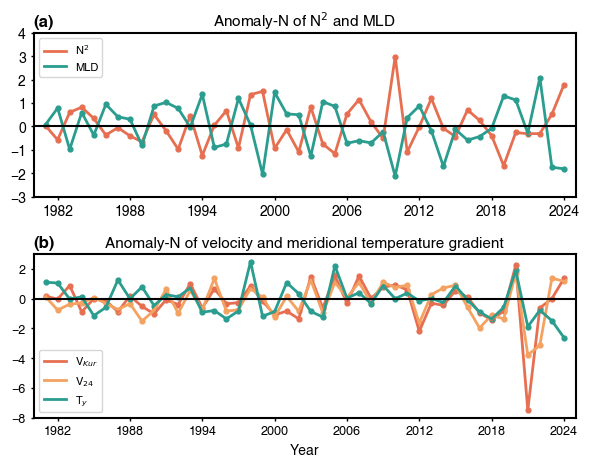

In [25]:
fig = plt.figure(figsize=(7, 5))
fig.subplots_adjust(hspace=0.35,wspace=0.07)
gs = GridSpec(2, 1, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(np.arange(1981,2025),(weight_mean_4d_full(N2[:,:31]*mask_hightemp,dx3,dy3,dz3)-np.mean(weight_mean_4d_full(N2[10:40,:31]*mask_hightemp,dx3,dy3,dz3)))
            /np.std(weight_mean_4d_full(N2[10:40,:31]*mask_hightemp,dx3,dy3,dz3)),lw=2,c='#E76F51',label='N$^2$')
ax1.scatter(np.arange(1981,2025),(weight_mean_4d_full(N2[:,:31]*mask_hightemp,dx3,dy3,dz3)-np.mean(weight_mean_4d_full(N2[10:40,:31]*mask_hightemp,dx3,dy3,dz3)))
            /np.std(weight_mean_4d_full(N2[10:40,:31]*mask_hightemp,dx3,dy3,dz3)),s=12,c='#E76F51')
ax1.plot(np.arange(1981,2025),(mld_his-np.mean(mld_his[10:40]))/np.std(mld_his[10:40]),lw=2,c='#2A9D8F',label='MLD')
ax1.scatter(np.arange(1981,2025),(mld_his-np.mean(mld_his[10:40]))/np.std(mld_his[10:40]),s=12,c='#2A9D8F')

ax1.plot(np.arange(1980,2026),np.full_like(np.arange(1980,2026),0),lw=1.5,c='k')

ax1.set_xlim([1980,2025])
ax1.set_xticks(np.arange(1982,2025,6))
ax1.set_xticklabels(np.arange(1982,2025,6),fontsize=10)
ax1.set_ylim([-3,4])
ax1.set_yticks([-3,-2,-1,0,1,2,3,4])
ax1.set_yticklabels(['−3','−2','−1','0','1','2','3','4'],fontsize=10)
ax1.tick_params(axis='both', length=2, width=1)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['top'].set_linewidth(1.5)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['right'].set_linewidth(1.5)
# ax1.set_xlabel('Year',fontsize=13)
# ax1.set_ylabel('Anomaly-N',fontsize=8,labelpad=0)
# ax1.grid()
ax1.legend(loc=2,fontsize=8)
ax1.set_title('(a)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax1.set_title('Anomaly-N of N$^2$ and MLD',fontsize=11,pad=5)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(np.arange(1981,2025),(uv_his-np.mean(uv_his[10:40]))/np.std(uv_his[10:40]),lw=2,c='#E76F51',label='V$_{Kur}$')
ax3.scatter(np.arange(1981,2025),(uv_his-np.mean(uv_his[10:40]))/np.std(uv_his[10:40]),s=12,c='#E76F51')
ax3.plot(np.arange(1981,2025),(vin_his-np.mean(vin_his[10:40]))/np.std(vin_his[10:40]),lw=2,c='#F4A261',label='V$_{24}$')
ax3.scatter(np.arange(1981,2025),(vin_his-np.mean(vin_his[10:40]))/np.std(vin_his[10:40]),s=12,c='#F4A261')
ax3.plot(np.arange(1981,2025),-1*(dtdy-np.mean(dtdy[10:40]))/np.std(dtdy[10:40]),lw=2,c='#2A9D8F',label='T$_y$')
ax3.scatter(np.arange(1981,2025),-1*(dtdy-np.mean(dtdy[10:40]))/np.std(dtdy[10:40]),s=12,c='#2A9D8F')

ax3.plot(np.arange(1980,2026),np.full_like(np.arange(1980,2026),0),lw=1.5,c='k')

ax3.set_xlim([1980,2025])
ax3.set_xticks(np.arange(1982,2025,6))
ax3.set_xticklabels(np.arange(1982,2025,6),fontsize=9)
ax3.set_ylim([-8,3])
ax3.set_yticks([-8,-6,-4,-2,0,2])
ax3.set_yticklabels(['−8','−6','−4','−2','0','2'],fontsize=9)
ax3.tick_params(axis='both', length=2, width=1)
ax3.spines['left'].set_linewidth(1.5)
ax3.spines['top'].set_linewidth(1.5)
ax3.spines['bottom'].set_linewidth(1.5)
ax3.spines['right'].set_linewidth(1.5)
ax3.set_xlabel('Year',fontsize=10)
# ax3.set_ylabel('Anomaly-N',fontsize=8,labelpad=0)
# ax3.grid()
ax3.legend(loc=3,fontsize=8)
ax3.set_title('(b)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax3.set_title('Anomaly-N of velocity and meridional temperature gradient',fontsize=11,pad=5)
# ax4 = fig.add_subplot(gs[:, 2], projection=ccrs.PlateCarree())
# ax4.set_extent([116,131,19.8,42])
# ax4.add_feature(cfeature.LAND.with_scale('50m'),facecolor='lightgray',zorder=1)
# ax4.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
# cs = ax4.contourf(Lon,Lat,(N2_year_89[-1]-np.mean(N2_year_89[10:40],0))/np.std(N2_year_89[10:40],0),
#                     levels= np.linspace(-3,3,13),cmap='coolwarm',extend='both')

# gl4 =ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl4.left_labels = True
# gl4.bottom_labels = True
# gl4.xformatter = LONGITUDE_FORMATTER
# gl4.yformatter = LATITUDE_FORMATTER
# gl4.xlabel_style = {'size': 8}
# gl4.ylabel_style = {'size': 8}
# ax4.set_xticks([117, 121, 125, 129])
# ax4.set_xticklabels([' ',' ',' ',' '])
# ax4.set_yticks([20, 25, 30, 35, 40])
# ax4.set_yticklabels([' ',' ',' ',' ',' '])
# gl4.xlocator = ticker.FixedLocator([117, 121, 125, 129])
# gl4.ylocator = ticker.FixedLocator([20,25, 30,35,40])
# ax4.tick_params(axis='both', length=2, width=1)

# ax5 = fig.add_subplot(gs[:, 3], projection=ccrs.PlateCarree())
# ax5.set_extent([116,131,19.8,42])
# ax5.add_feature(cfeature.LAND.with_scale('50m'),facecolor='lightgray',zorder=1)
# ax5.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
# cs = ax5.contourf(Lon,Lat,-1*(sel_year(np.gradient(t_mld,axis=1),8,9)[-1]-np.mean(sel_year(np.gradient(t_mld,axis=1),8,9)[10:40],0))/np.std(sel_year(np.gradient(t_mld,axis=1),8,9)[10:40],0),
#                     levels= np.linspace(-3,3,13),cmap='coolwarm',extend='both')

# gl5 =ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# # gl5.left_labels = True
# gl5.bottom_labels = True
# gl5.xformatter = LONGITUDE_FORMATTER
# gl5.yformatter = LATITUDE_FORMATTER
# gl5.xlabel_style = {'size': 8}
# gl5.ylabel_style = {'size': 8}
# ax5.set_xticks([117, 121, 125, 129])
# ax5.set_xticklabels([' ',' ',' ',' '])
# ax5.set_yticks([20, 25, 30, 35, 40])
# ax5.set_yticklabels([' ',' ',' ',' ',' '])
# gl5.xlocator = ticker.FixedLocator([117, 121, 125, 129])
# gl5.ylocator = ticker.FixedLocator([20,25, 30,35,40])
# ax5.tick_params(axis='both', length=2, width=1)

# ax4.spines['geo'].set_linewidth(1.5)
# ax5.spines['geo'].set_linewidth(1.5)

# ax4.set_title('c',fontsize=8,loc='left',fontweight='bold',pad=2)
# ax5.set_title('d',fontsize=8,loc='left',fontweight='bold',pad=2)
# ax4.set_title('N$^2$ anomaly-N',fontsize=8,pad=2)
# ax5.set_title('T$_y$ anomaly-N',fontsize=8,pad=2)

# cax = add_bottom_cax_big(ax4,ax5, pad=0.065, width=0.018)
# cb =  fig.colorbar(cs,cax=cax,drawedges=True,orientation='horizontal')
# cb.set_ticks([-3,-2,-1,0,1,2,3])
# cb.set_ticklabels(['−3','−2','−1','0','1','2','3'],fontsize=8)
# cb.outline.set_edgecolor('black')
# cb.outline.set_linewidth(1.2)
# cb.dividers.set_linewidth(1)
fig_format = 'pdf'
fig.savefig('./ERL/FigS3.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')
fig.savefig('./ERL/FigS3.png', format='png', dpi = 300, bbox_inches='tight')